In [1]:
import os

# Path to your dataset
DATASET_ROOT = "dropbox"

# List categories
categories = os.listdir(DATASET_ROOT)
categories = [c for c in categories if os.path.isdir(os.path.join(DATASET_ROOT, c))]
print("Categories found:", categories)

Categories found: ['Chair', 'Bag']


In [2]:
category = "Chair"
category_path = os.path.join(DATASET_ROOT, category)

for subfolder in os.listdir(category_path):
    subfolder_path = os.path.join(category_path, subfolder)
    if os.path.isdir(subfolder_path):
        files = os.listdir(subfolder_path)
        print(f"{subfolder}: {len(files)} files, sample:", files[:5])

syms: 6201 files, sample: ['259.mat', '1915.mat', '3864.mat', '3870.mat', '1901.mat']
labels: 6201 files, sample: ['259.mat', '1915.mat', '3864.mat', '3870.mat', '1901.mat']
models: 6201 files, sample: ['2819.obj', '43912.obj', '39066.obj', '38378.obj', '36433.obj']
part mesh indices: 6201 files, sample: ['259.mat', '1915.mat', '3864.mat', '3870.mat', '1901.mat']
obbs: 6201 files, sample: ['2629.obb', '40559.obb', '37909.obb', '35878.obb', '3251.obb']
ops: 6201 files, sample: ['259.mat', '1915.mat', '3864.mat', '3870.mat', '1901.mat']
boxes: 6201 files, sample: ['259.mat', '1915.mat', '3864.mat', '3870.mat', '1901.mat']


In [3]:
import scipy.io

shape_id = 259
ops_file = os.path.join(DATASET_ROOT, category, "ops", f"{shape_id}.mat")

# Load the .mat file
ops_data = scipy.io.loadmat(ops_file)
print(ops_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'op'])


In [4]:
# Extract the node types
node_types = ops_data['op']
print("Shape of node_types:", node_types.shape)
print("First 10 node types:", node_types[:10])

Shape of node_types: (1, 16)
First 10 node types: [[0 0 0 1 2 1 0 0 1 2 0 0 2 1 1 1]]


In [5]:
# Load part mesh indices
part_mesh_file = os.path.join(DATASET_ROOT, category, "part mesh indices", f"{shape_id}.mat")
part_mesh_data = scipy.io.loadmat(part_mesh_file)
print(part_mesh_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'cell_boxs_correspond_objSerialNumber', 'shapename'])


In [6]:
# Extract the part mesh indices
part_mesh_indices = part_mesh_data['cell_boxs_correspond_objSerialNumber']
print("Type:", type(part_mesh_indices))
print("Shape:", part_mesh_indices.shape)
print("Content sample:", part_mesh_indices[:5])

Type: <class 'numpy.ndarray'>
Shape: (1, 7)
Content sample: [[array([[8]], dtype=uint8) array([[10]], dtype=uint8)
  array([[12, 13]], dtype=uint8) array([[6]], dtype=uint8)
  array([[5]], dtype=uint8) array([[7]], dtype=uint8)
  array([[4]], dtype=uint8)]]


In [7]:
import glob

models_path = os.path.join(DATASET_ROOT, category, "models")
all_objs = sorted(glob.glob(os.path.join(models_path, "*.obj")), key=lambda x: int(x.split("/")[-1].split(".")[0]))

# Map leaf nodes to .obj files
leaf_to_obj = []
for leaf in part_mesh_indices[0]:
    # Some leaf nodes have multiple mesh indices
    meshes = [all_objs[i-1] for i in leaf[0]]  # MATLAB indices start at 1
    leaf_to_obj.append(meshes)

for i, meshes in enumerate(leaf_to_obj):
    print(f"Leaf node {i}: {meshes}")

Leaf node 0: ['dropbox/Chair/models/186.obj']
Leaf node 1: ['dropbox/Chair/models/197.obj']
Leaf node 2: ['dropbox/Chair/models/267.obj', 'dropbox/Chair/models/272.obj']
Leaf node 3: ['dropbox/Chair/models/182.obj']
Leaf node 4: ['dropbox/Chair/models/178.obj']
Leaf node 5: ['dropbox/Chair/models/183.obj']
Leaf node 6: ['dropbox/Chair/models/177.obj']


In [8]:
# Load labels
labels_file = os.path.join(DATASET_ROOT, category, "labels", f"{shape_id}.mat")
labels_data = scipy.io.loadmat(labels_file)
print(labels_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'label'])


In [9]:
# Extract labels for leaf nodes
node_labels = labels_data['label'][0]  # assuming MATLAB 1×N array
print("Node labels shape:", node_labels.shape)
print("Labels for each leaf node:", node_labels)

Node labels shape: (7,)
Labels for each leaf node: [1 2 2 0 0 0 0]


In [10]:
# Load bounding boxes
boxes_file = os.path.join(DATASET_ROOT, category, "boxes", f"{shape_id}.mat")
boxes_data = scipy.io.loadmat(boxes_file)
print(boxes_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'box'])


In [11]:
# Extract bounding boxes for leaf nodes
leaf_boxes = boxes_data['box'][0]  # assuming MATLAB 1×N array
print("Number of leaf boxes:", len(leaf_boxes))
print("Sample leaf box:", leaf_boxes[0])

Number of leaf boxes: 7
Sample leaf box: 0.0006165


In [12]:
# Print full data for first leaf box
print("Full first leaf box data:", leaf_boxes[0])
print("Shape:", leaf_boxes[0].shape)

Full first leaf box data: 0.0006165
Shape: ()


In [13]:
# Check the full 'box' array
print("boxes_data['box'] type:", type(boxes_data['box']))
print("boxes_data['box'] shape:", boxes_data['box'].shape)
print("boxes_data['box'] sample element:", boxes_data['box'][0])

boxes_data['box'] type: <class 'numpy.ndarray'>
boxes_data['box'] shape: (12, 7)
boxes_data['box'] sample element: [ 0.0006165 -0.300891  -0.300891  -0.265489  -0.16619   -0.0250115
 -0.057481 ]


In [14]:
leaf_index = 0
leaf_box = boxes_data['box'][:, leaf_index]
print(f"Bounding box for leaf node {leaf_index}:", leaf_box)
print("Shape:", leaf_box.shape)  # should be (12,)

Bounding box for leaf node 0: [6.16500e-04 2.35650e-02 7.86515e-02 1.26728e-01 1.00499e+00 7.44767e-01
 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00]
Shape: (12,)


In [15]:
# Example for one shape (Chair)
leaf_node_to_mesh = [
    ['dropbox/Chair/models/186.obj'],
    ['dropbox/Chair/models/197.obj'],
    ['dropbox/Chair/models/267.obj', 'dropbox/Chair/models/272.obj'],
    ['dropbox/Chair/models/182.obj'],
    ['dropbox/Chair/models/178.obj'],
    ['dropbox/Chair/models/183.obj'],
    ['dropbox/Chair/models/177.obj']
]

# Assuming labels and boxes are already loaded as 'labels' and 'boxes'

# Collect leaf node info
num_leaf_nodes = len(leaf_node_to_mesh)
leaf_nodes_info = []

for i in range(num_leaf_nodes):
    mesh = leaf_node_to_mesh[i]            # mesh paths
    label = labels[i]                      # node label
    bbox = boxes[:, i]                      # bounding box (12,)
    
    leaf_nodes_info.append({
        "mesh": mesh,
        "label": label,
        "bbox": bbox
    })

# Print first 3 leaf nodes as a sample
for i, info in enumerate(leaf_nodes_info[:3]):
    print(f"Leaf node {i}:")
    print(f" Mesh: {info['mesh']}")
    print(f" Label: {info['label']}")
    print(f" Bounding box: {info['bbox']}")
    print("-" * 30)

NameError: name 'labels' is not defined

In [ ]:
import os
import scipy.io

category = "Chair"
shape_id = "259"  # example
DATASET_ROOT = "dropbox"

# Load leaf node meshes
part_indices_file = os.path.join(DATASET_ROOT, category, "part mesh indices", f"{shape_id}.mat")
part_indices_data = scipy.io.loadmat(part_indices_file)
leaf_node_to_mesh = part_indices_data['cell_boxs_correspond_objSerialNumber'][0]  # adjust indexing if needed

# Convert MATLAB arrays to Python lists of file paths
for i in range(len(leaf_node_to_mesh)):
    leaf_node_to_mesh[i] = [os.path.join(DATASET_ROOT, category, "models", str(int(idx)) + ".obj") for idx in leaf_node_to_mesh[i][0]]

# Load labels
labels_file = os.path.join(DATASET_ROOT, category, "labels", f"{shape_id}.mat")
labels_data = scipy.io.loadmat(labels_file)
labels = labels_data['label'].flatten()  # make it 1D

# Load bounding boxes
boxes_file = os.path.join(DATASET_ROOT, category, "boxes", f"{shape_id}.mat")
boxes_data = scipy.io.loadmat(boxes_file)
boxes = boxes_data['box']  # (12, num_leaf_nodes)

print("Leaf meshes:", leaf_node_to_mesh)
print("Labels:", labels)
print("Boxes shape:", boxes.shape)

Leaf meshes: [list(['dropbox/Chair/models/8.obj'])
 list(['dropbox/Chair/models/10.obj'])
 list(['dropbox/Chair/models/12.obj', 'dropbox/Chair/models/13.obj'])
 list(['dropbox/Chair/models/6.obj']) list(['dropbox/Chair/models/5.obj'])
 list(['dropbox/Chair/models/7.obj']) list(['dropbox/Chair/models/4.obj'])]
Labels: [1 2 2 0 0 0 0]
Boxes shape: (12, 7)


ValueError: string is not a file: `dropbox/Chair/models/8.obj`

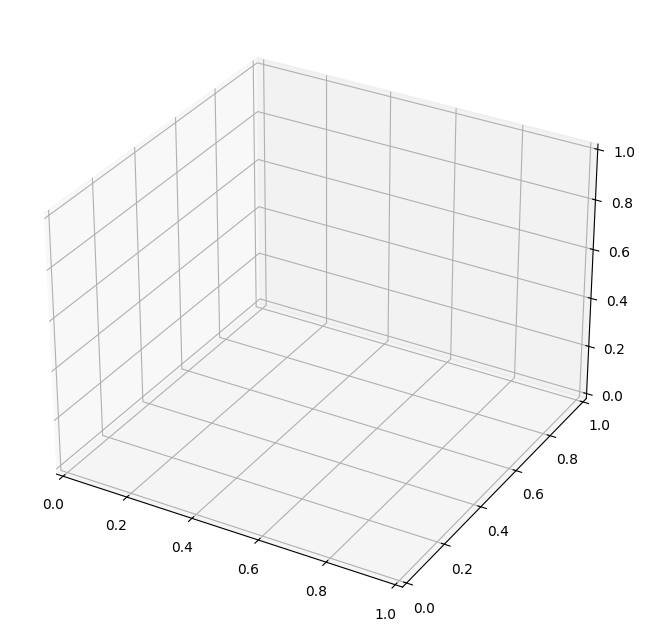

In [16]:
import trimesh
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

leaf_meshes = [
    ['dropbox/Chair/models/8.obj'],
    ['dropbox/Chair/models/10.obj'],
    ['dropbox/Chair/models/12.obj', 'dropbox/Chair/models/13.obj'],
    ['dropbox/Chair/models/6.obj'],
    ['dropbox/Chair/models/5.obj'],
    ['dropbox/Chair/models/7.obj'],
    ['dropbox/Chair/models/4.obj']
]

labels = np.array([1, 2, 2, 0, 0, 0, 0])
boxes = boxes_data['box']  # Already loaded, shape (12,7)

def plot_leaf_meshes_with_boxes(leaf_meshes, boxes, labels):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    for i, meshes in enumerate(leaf_meshes):
        # Load and plot all meshes in this leaf node
        for mesh_path in meshes:
            mesh = trimesh.load(mesh_path)
            vertices = mesh.vertices
            faces = mesh.faces
            
            mesh_collection = Poly3DCollection(vertices[faces], alpha=0.3)
            # Color by label
            color = plt.cm.tab10(labels[i] % 10)
            mesh_collection.set_facecolor(color)
            ax.add_collection3d(mesh_collection)
        
        # Plot bounding box
        box = boxes[:, i]
        plot_bbox(ax, box)
    
    set_axes_equal(ax)
    plt.show()

def plot_bbox(ax, box):
    # Assuming box format: [cx, cy, cz, dx, dy, dz, r11, r12, r13, r21, r22, r23]
    # You may need to adjust depending on the box format
    cx, cy, cz = box[0], box[1], box[2]
    dx, dy, dz = box[3], box[4], box[5]
    
    # Create a simple rectangular prism
    x = [cx-dx/2, cx+dx/2]
    y = [cy-dy/2, cy+dy/2]
    z = [cz-dz/2, cz+dz/2]
    
    for xi in x:
        for yi in y:
            for zi in z:
                ax.scatter(xi, yi, zi, color='k', s=1)  # corners
    
def set_axes_equal(ax):
    '''Set 3D plot axes to equal scale.'''
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d()
    ])
    spans = limits[:,1] - limits[:,0]
    centers = np.mean(limits, axis=1)
    maxspan = max(spans)/2
    ax.set_xlim3d(centers[0]-maxspan, centers[0]+maxspan)
    ax.set_ylim3d(centers[1]-maxspan, centers[1]+maxspan)
    ax.set_zlim3d(centers[2]-maxspan, centers[2]+maxspan)

# Call the function
plot_leaf_meshes_with_boxes(leaf_meshes, boxes, labels)

In [17]:
import os
import trimesh

# Fix leaf mesh paths
leaf_meshes_full = [
    [os.path.join(DATASET_ROOT, mesh) for mesh in leaf]
    for leaf in leaf_meshes
]

# Example: load the first mesh to check
mesh0 = trimesh.load(leaf_meshes_full[0][0])
mesh0.show()

ValueError: string is not a file: `dropbox/dropbox/Chair/models/8.obj`

In [18]:
import os
import trimesh

# Remove the leading 'dropbox/' from each path
leaf_meshes_full = [
    [os.path.join(DATASET_ROOT, mesh_path.replace("dropbox/", "")) for mesh_path in leaf]
    for leaf in leaf_meshes
]

# Test by loading the first mesh
mesh0 = trimesh.load(leaf_meshes_full[0][0])
mesh0.show()

ValueError: string is not a file: `dropbox/Chair/models/8.obj`

In [19]:
# List all model files sorted by filename number
import glob

model_files = sorted(glob.glob(os.path.join(DATASET_ROOT, category, "models", "*.obj")),
                     key=lambda x: int(os.path.splitext(os.path.basename(x))[0]))

# Map leaf node indices to actual filenames
leaf_meshes_corrected = [
    [model_files[i] for i in leaf]  # i is the index stored in cell_boxs_correspondence_objSerialNumber
    for leaf in leaf_node_to_mesh
]

TypeError: list indices must be integers or slices, not str

Labels shape: (7,)
Labels: [1 2 2 0 0 0 0]
Boxes shape: (12, 7)


ValueError: cannot reshape array of size 6 into shape (3,3)

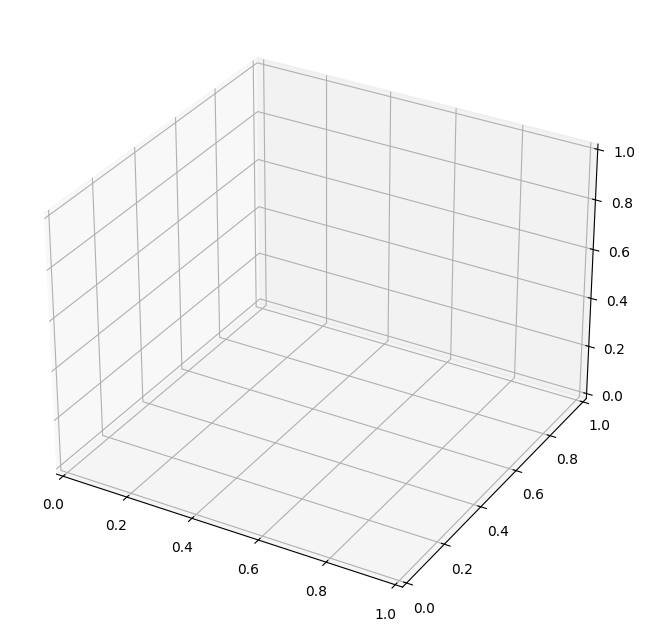

In [1]:
# loader.ipynb

import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---------- CONFIG ----------
DATASET_ROOT = 'dropbox'
category = 'Chair'
shape_id = '259'  # pick one sample from your dataset

# ---------- LOAD LABELS ----------
labels_file = os.path.join(DATASET_ROOT, category, "labels", f"{shape_id}.mat")
labels_data = scipy.io.loadmat(labels_file)
labels = labels_data['label'].flatten()
print("Labels shape:", labels.shape)
print("Labels:", labels)

# ---------- LOAD BOXES ----------
boxes_file = os.path.join(DATASET_ROOT, category, "boxes", f"{shape_id}.mat")
boxes_data = scipy.io.loadmat(boxes_file)
boxes = boxes_data['box']
print("Boxes shape:", boxes.shape)

# ---------- PLOT FUNCTION ----------
def plot_bbox(ax, center, size, R=np.eye(3), color='cyan'):
    dx, dy, dz = size
    # 8 corners in local coords
    x = np.array([0, dx, dx, 0, 0, dx, dx, 0]) - dx/2
    y = np.array([0, 0, dy, dy, 0, 0, dy, dy]) - dy/2
    z = np.array([0, 0, 0, 0, dz, dz, dz, dz]) - dz/2
    corners = np.vstack([x, y, z]).T
    # apply rotation
    corners = (R @ corners.T).T
    # translate to center
    corners += center
    # cube faces
    faces = [
        [corners[j] for j in [0,1,2,3]],
        [corners[j] for j in [4,5,6,7]],
        [corners[j] for j in [0,1,5,4]],
        [corners[j] for j in [2,3,7,6]],
        [corners[j] for j in [1,2,6,5]],
        [corners[j] for j in [4,7,3,0]],
    ]
    ax.add_collection3d(Poly3DCollection(faces, facecolors=color, linewidths=0.5, edgecolors='k', alpha=0.3))

# ---------- VISUALIZE ALL LEAF NODES ----------
colors = ['cyan', 'magenta', 'yellow', 'green', 'orange', 'blue', 'red']

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

num_leafs = boxes.shape[1]

for i in range(num_leafs):
    bbox = boxes[:, i]
    center = bbox[:3]
    size = bbox[3:6]
    R = bbox[6:].reshape(3,3)
    color = colors[labels[i] % len(colors)]
    plot_bbox(ax, center, size, R, color=color)

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title(f"{category} shape {shape_id} - Bounding Boxes Only")
plt.show()

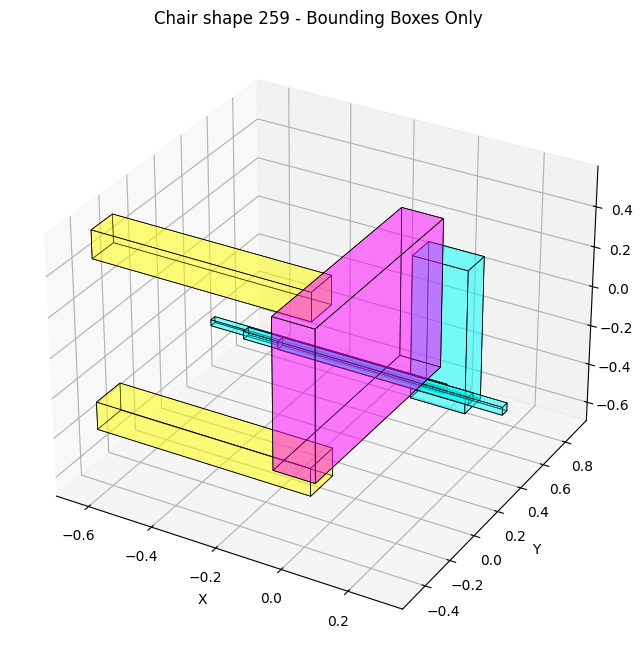

In [2]:
# VISUALIZE ALL LEAF NODES WITHOUT ROTATION
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

num_leafs = boxes.shape[1]

for i in range(num_leafs):
    bbox = boxes[:, i]
    center = bbox[:3]       # x, y, z
    size = bbox[3:6]        # dx, dy, dz
    color = colors[labels[i] % len(colors)]
    plot_bbox(ax, center, size, R=np.eye(3), color=color)  # ignore rotation

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title(f"{category} shape {shape_id} - Bounding Boxes Only")
plt.show()

In [3]:
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Adjust to your dataset root
DATASET_ROOT = "dropbox"
category = "Chair"
shape_id = "1"  # replace with one shape id you want to test

# Load boxes
boxes_file = os.path.join(DATASET_ROOT, category, "boxes", f"{shape_id}.mat")
boxes_data = scipy.io.loadmat(boxes_file)
print("Keys in boxes_data:", boxes_data.keys())

# Take first box array
boxes = boxes_data['box']
print("Shape of boxes array:", boxes.shape)
print("First 6 elements of first box:", boxes[:6,0])

Keys in boxes_data: dict_keys(['__header__', '__version__', '__globals__', 'box'])
Shape of boxes array: (12, 3)
First 6 elements of first box: [0.0030865 0.148677  0.0724135 0.223845  0.805681  0.890567 ]


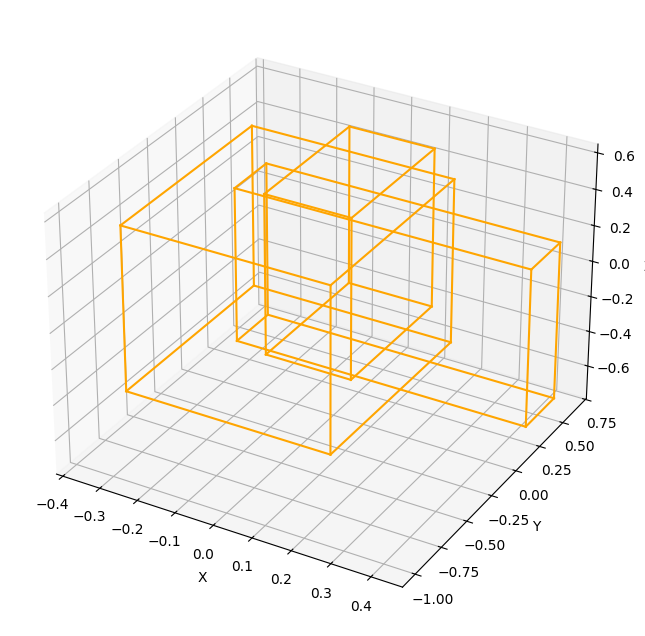

In [4]:
def plot_cube(ax, center, size, color='blue'):
    """
    Plot a cube given center and size (ignoring rotation for now)
    """
    # Compute corner coordinates
    l, w, h = size
    x = [center[0]-l/2, center[0]+l/2]
    y = [center[1]-w/2, center[1]+w/2]
    z = [center[2]-h/2, center[2]+h/2]

    # Draw cube lines
    for xi in x:
        for yi in y:
            ax.plot([xi, xi], [yi, yi], z, color=color)
    for xi in x:
        for zi in z:
            ax.plot([xi, xi], y, [zi, zi], color=color)
    for yi in y:
        for zi in z:
            ax.plot(x, [yi, yi], [zi, zi], color=color)

# Plot all boxes
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

for i in range(boxes.shape[1]):
    center = boxes[:3,i]
    size = boxes[3:6,i]
    plot_cube(ax, center, size, color='orange')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

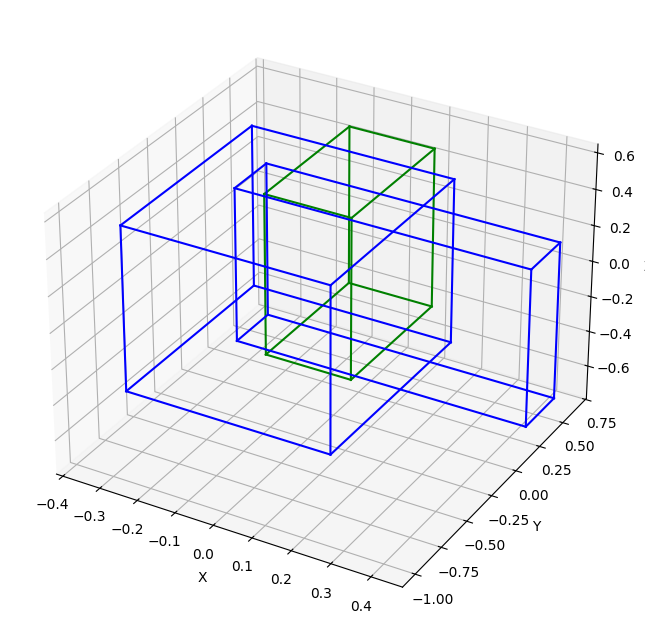

In [5]:
# Define colors for labels
label_colors = {0: 'red', 1: 'green', 2: 'blue', 3: 'yellow'}

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

for i in range(boxes.shape[1]):
    center = boxes[:3, i]
    size = boxes[3:6, i]
    label = labels[i]
    color = label_colors.get(label, 'gray')
    plot_cube(ax, center, size, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

In [6]:
import k3d
import numpy as np

# Function to create vertices and indices for a cube given center and size
def create_cube(center, size):
    cx, cy, cz = center
    sx, sy, sz = size / 2  # half-sizes
    # 8 vertices of the cube
    vertices = np.array([
        [cx-sx, cy-sy, cz-sz],
        [cx+sx, cy-sy, cz-sz],
        [cx+sx, cy+sy, cz-sz],
        [cx-sx, cy+sy, cz-sz],
        [cx-sx, cy-sy, cz+sz],
        [cx+sx, cy-sy, cz+sz],
        [cx+sx, cy+sy, cz+sz],
        [cx-sx, cy+sy, cz+sz],
    ], dtype=np.float32)
    # 12 triangles of the cube
    indices = np.array([
        [0,1,2],[0,2,3], [4,5,6],[4,6,7],
        [0,1,5],[0,5,4], [2,3,7],[2,7,6],
        [1,2,6],[1,6,5], [0,3,7],[0,7,4]
    ], dtype=np.uint32)
    return vertices, indices

# Define colors for labels
label_colors = {0: 0xff0000, 1: 0x00ff00, 2: 0x0000ff, 3: 0xffff00}

plot = k3d.plot(height=600)

for i in range(boxes.shape[1]):
    center = boxes[:3, i]
    size = boxes[3:6, i]
    label = labels[i]
    color = label_colors.get(label, 0x888888)
    
    vertices, indices = create_cube(center, size)
    mesh = k3d.mesh(vertices, indices, color=color, wireframe=True)
    plot += mesh

plot.display()

Output()

In [7]:
import k3d
import numpy as np

def create_cube(center, size):
    cx, cy, cz = center
    sx, sy, sz = size / 2
    vertices = np.array([
        [cx-sx, cy-sy, cz-sz],
        [cx+sx, cy-sy, cz-sz],
        [cx+sx, cy+sy, cz-sz],
        [cx-sx, cy+sy, cz-sz],
        [cx-sx, cy-sy, cz+sz],
        [cx+sx, cy-sy, cz+sz],
        [cx+sx, cy+sy, cz+sz],
        [cx-sx, cy+sy, cz+sz],
    ], dtype=np.float32)
    indices = np.array([
        [0,1,2],[0,2,3], [4,5,6],[4,6,7],
        [0,1,5],[0,5,4], [2,3,7],[2,7,6],
        [1,2,6],[1,6,5], [0,3,7],[0,7,4]
    ], dtype=np.uint32)
    return vertices, indices

label_colors = {0: 0xff0000, 1: 0x00ff00, 2: 0x0000ff, 3: 0xffff00}

plot = k3d.plot(height=700, background_color=0xffffff)

for i in range(boxes.shape[1]):
    center = boxes[:3, i]
    size = boxes[3:6, i]
    label = labels[i]
    color = label_colors.get(label, 0x888888)
    
    vertices, indices = create_cube(center, size)
    mesh = k3d.mesh(vertices, indices, color=color, wireframe=True, opacity=0.5)
    plot += mesh

plot.display()

Output()

In [8]:
import k3d
import numpy as np

def create_cube(center, size, rotation=np.eye(3)):
    cx, cy, cz = center
    sx, sy, sz = size / 2

    # Cube vertices in local coordinates
    vertices = np.array([
        [-sx,-sy,-sz],[ sx,-sy,-sz],[ sx, sy,-sz],[-sx, sy,-sz],
        [-sx,-sy, sz],[ sx,-sy, sz],[ sx, sy, sz],[-sx, sy, sz]
    ], dtype=np.float32)
    
    # Apply rotation
    vertices = vertices @ rotation.T
    # Translate to center
    vertices += center
    
    indices = np.array([
        [0,1,2],[0,2,3], [4,5,6],[4,6,7],
        [0,1,5],[0,5,4], [2,3,7],[2,7,6],
        [1,2,6],[1,6,5], [0,3,7],[0,7,4]
    ], dtype=np.uint32)
    
    return vertices, indices

label_colors = {0: 0xff0000, 1: 0x00ff00, 2: 0x0000ff, 3: 0xffff00}

# Example per-part transformations (identity = no rotation)
rotations = [np.eye(3) for _ in range(boxes.shape[1])]
translations = [boxes[:3,i] for i in range(boxes.shape[1])]
scales = [boxes[3:6,i] for i in range(boxes.shape[1])]

plot = k3d.plot(height=700, background_color=0xffffff)

for i in range(boxes.shape[1]):
    center = translations[i]
    size = scales[i]
    rotation = rotations[i]
    label = labels[i]
    color = label_colors.get(label, 0x888888)
    
    vertices, indices = create_cube(center, size, rotation)
    mesh = k3d.mesh(vertices, indices, color=color, wireframe=True, opacity=0.5)
    plot += mesh

plot.display()

/opt/homebrew/Caskroom/miniconda/base/envs/abs/lib/python3.12/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(


Output()

In [10]:
import k3d
import numpy as np

def create_cube(center, size, rotation=np.eye(3)):
    cx, cy, cz = center
    sx, sy, sz = size / 2

    vertices = np.array([
        [-sx,-sy,-sz],[ sx,-sy,-sz],[ sx, sy,-sz],[-sx, sy,-sz],
        [-sx,-sy, sz],[ sx,-sy, sz],[ sx, sy, sz],[-sx, sy, sz]
    ], dtype=np.float32)
    
    # Apply rotation
    vertices = vertices @ rotation.T
    # Translate to center
    vertices += center
    
    indices = np.array([
        [0,1,2],[0,2,3], [4,5,6],[4,6,7],
        [0,1,5],[0,5,4], [2,3,7],[2,7,6],
        [1,2,6],[1,6,5], [0,3,7],[0,7,4]
    ], dtype=np.uint32)
    
    return vertices, indices

def visualize_shape(boxes, labels):
    # label to color mapping
    label_colors = {0: 0xff0000, 1: 0x00ff00, 2: 0x0000ff, 3: 0xffff00}
    
    plot = k3d.plot(height=700, background_color=0xffffff)
    
    for i in range(boxes.shape[1]):
        center = boxes[:3,i]
        size = boxes[3:6,i]
        rotation = np.eye(3)  # can customize per leaf
        label = labels[i]
        color = label_colors.get(label, 0x888888)
        
        vertices, indices = create_cube(center, size, rotation)
        mesh = k3d.mesh(vertices, indices, color=color, wireframe=True, opacity=0.5)
        plot += mesh
    
    plot.display()

# Example usage for random shapes
# Assuming you have loaded boxes_data and labels_data
boxes = boxes_data['box']  # shape (12, num_leaf_nodes)
labels = labels_data['label'].flatten()  # shape (num_leaf_nodes,)

visualize_shape(boxes, labels)

Output()

In [13]:
import os
import random
import scipy.io
import numpy as np

# Path to your dataset
DATASET_ROOT = "dropbox/Chair"

# List all shape IDs (assuming folder structure: dropbox/Chair/<shape_id>)
shape_ids = [f.split('.')[0] for f in os.listdir(os.path.join(DATASET_ROOT, "boxes")) if f.endswith('.mat')]

# Pick a random shape
shape_id = random.choice(shape_ids)
print(f"Randomly selected shape: {shape_id}")

# Load bounding boxes
boxes_file = os.path.join(DATASET_ROOT, "boxes", f"{shape_id}.mat")
boxes_data = scipy.io.loadmat(boxes_file)
boxes = boxes_data['box']  # shape (12, num_leaf_nodes)

# Load labels
labels_file = os.path.join(DATASET_ROOT, "labels", f"{shape_id}.mat")
labels_data = scipy.io.loadmat(labels_file)
labels = labels_data['label'].flatten()  # shape (num_leaf_nodes,)

# --- Use the previous visualize_shape function ---
visualize_shape(boxes, labels)

Randomly selected shape: 73


Output()

In [14]:
import os
import random
import scipy.io
import numpy as np
import k3d

# Function to visualize bounding boxes
def visualize_shape(boxes, labels):
    plot = k3d.plot()
    colors = [0xff0000, 0x00ff00, 0x0000ff, 0xffff00]  # example colors for 4 labels

    num_boxes = boxes.shape[1]
    for i in range(num_boxes):
        bbox = boxes[:, i]
        center = bbox[:3]
        size = bbox[3:6]
        print(f"Leaf node {i}:")
        print(f"  Label: {labels[i]}")
        print(f"  Center: {center}")
        print(f"  Size: {size}\n")
        box_mesh = k3d.mesh(np.array([
            [0,0,0], [1,0,0], [1,1,0], [0,1,0],
            [0,0,1], [1,0,1], [1,1,1], [0,1,1]
        ]) * size + center, indices=[
            0,1,2, 0,2,3,  # bottom
            4,5,6, 4,6,7,  # top
            0,1,5, 0,5,4,  # side1
            1,2,6, 1,6,5,  # side2
            2,3,7, 2,7,6,  # side3
            3,0,4, 3,4,7   # side4
        ], color=colors[labels[i] % len(colors)])
        plot += box_mesh

    plot.display()

# Path to your dataset
DATASET_ROOT = "dropbox/Chair"

# List all shape IDs
shape_ids = [f.split('.')[0] for f in os.listdir(os.path.join(DATASET_ROOT, "boxes")) if f.endswith('.mat')]

# Pick a random shape
shape_id = random.choice(shape_ids)
print(f"Randomly selected shape: {shape_id}")

# Load bounding boxes
boxes_file = os.path.join(DATASET_ROOT, "boxes", f"{shape_id}.mat")
boxes_data = scipy.io.loadmat(boxes_file)
boxes = boxes_data['box']

# Load labels
labels_file = os.path.join(DATASET_ROOT, "labels", f"{shape_id}.mat")
labels_data = scipy.io.loadmat(labels_file)
labels = labels_data['label'].flatten()

# Visualize
visualize_shape(boxes, labels)

Randomly selected shape: 2769
Leaf node 0:
  Label: 1
  Center: [-0.013129  -0.0650575  0.125759 ]
  Size: [0.042903 0.772247 0.772248]

Leaf node 1:
  Label: 2
  Center: [-0.350988 -0.3846   -0.212265]
  Size: [0.607822 0.098929 0.099263]

Leaf node 2:
  Label: 2
  Center: [-0.350988 -0.386827  0.399263]
  Size: [0.600636 0.096531 0.096531]

Leaf node 3:
  Label: 0
  Center: [-0.011795  0.438227 -0.21931 ]
  Size: [0.710495 0.054872 0.573786]

Leaf node 4:
  Label: 0
  Center: [-0.335866  0.379115 -0.212099]
  Size: [1.02355  0.099263 0.129507]



Output()

In [15]:
import os
import random
import scipy.io
import numpy as np
import k3d

DATASET_ROOT = "dropbox/Chair"

def load_random_chair():
    shape_ids = [f.split('.')[0] for f in os.listdir(os.path.join(DATASET_ROOT, "boxes")) if f.endswith('.mat')]
    shape_id = random.choice(shape_ids)
    print(f"Selected shape: {shape_id}")

    # Load boxes and labels
    boxes_data = scipy.io.loadmat(os.path.join(DATASET_ROOT, "boxes", f"{shape_id}.mat"))
    labels_data = scipy.io.loadmat(os.path.join(DATASET_ROOT, "labels", f"{shape_id}.mat"))
    
    boxes = boxes_data['box']  # shape (num_parts, 6)
    labels = labels_data['label'].flatten()  # shape (num_parts,)
    
    return boxes, labels

def visualize_boxes_k3d(boxes, labels):
    plot = k3d.plot()
    colors = [0x00ffff, 0xff00ff, 0xffff00, 0xff8800]  # back, seat, leg, armrest

    for i in range(boxes.shape[0]):
        center = boxes[i, :3]
        size = boxes[i, 3:6]
        print(f"Leaf {i} - Label {labels[i]} - Center {center} - Size {size}")

        # Define cube vertices
        cube_vertices = np.array([
            [0,0,0], [1,0,0], [1,1,0], [0,1,0],
            [0,0,1], [1,0,1], [1,1,1], [0,1,1]
        ]) * size + center

        cube_indices = np.array([
            0,1,2, 0,2,3,  # bottom
            4,5,6, 4,6,7,  # top
            0,1,5, 0,5,4,  # side1
            1,2,6, 1,6,5,  # side2
            2,3,7, 2,7,6,  # side3
            3,0,4, 3,4,7   # side4
        ])

        plot += k3d.mesh(cube_vertices, cube_indices, color=colors[labels[i] % len(colors)], opacity=0.5)

    plot.display()

boxes, labels = load_random_chair()
visualize_boxes_k3d(boxes, labels)

Selected shape: 3829
Leaf 0 - Label 1 - Center [-0.001005 -0.54636  -0.575962] - Size [-0.411294   0.0273165]


ValueError: operands could not be broadcast together with shapes (8,3) (2,) 

In [16]:
import numpy as np
import k3d
import math

# Example data - replace with your actual loaded arrays
# boxes: (N,6) -> [cx,cy,cz, sx,sy,sz]
# labels: (N,) -> integer label per leaf
# colors: color map for labels
boxes = np.array([
    [0, 0, 0, 0.2, 0.2, 0.05],  # seat
    [-0.1, -0.1, -0.25, 0.05, 0.05, 0.5],  # leg1
    [0.1, -0.1, -0.25, 0.05, 0.05, 0.5],   # leg2
    [-0.1, 0.1, -0.25, 0.05, 0.05, 0.5],   # leg3
    [0.1, 0.1, -0.25, 0.05, 0.05, 0.5],    # leg4
    [0, 0.15, 0.05, 0.2, 0.05, 0.25]       # backrest
], dtype=np.float32)
labels = np.array([1, 2, 2, 2, 2, 0])
colors = [0xff0000, 0x00ff00, 0x0000ff, 0xffff00]  # red, green, blue, yellow

plot = k3d.plot()
plot.display()

def rotation_matrix(axis, theta):
    """
    Return the rotation matrix associated with counterclockwise rotation about
    the given axis by theta radians using Rodrigues' formula.
    """
    axis = np.asarray(axis)
    axis = axis / math.sqrt(np.dot(axis, axis))
    a = math.cos(theta/2.0)
    b, c, d = -axis * math.sin(theta/2.0)
    return np.array([
        [a*a + b*b - c*c - d*d, 2*(b*c - a*d),       2*(b*d + a*c)],
        [2*(b*c + a*d),       a*a + c*c - b*b - d*d, 2*(c*d - a*b)],
        [2*(b*d - a*c),       2*(c*d + a*b),       a*a + d*d - b*b - c*c]
    ], dtype=np.float32)

for i in range(boxes.shape[0]):
    center = boxes[i, :3].astype(np.float32)
    size = boxes[i, 3:6].astype(np.float32)
    
    # Example rotation: backrest tilted slightly
    if labels[i] == 0:  # backrest
        R = rotation_matrix([1,0,0], np.radians(-10))
    else:
        R = np.eye(3, dtype=np.float32)

    print(f"Plotting leaf {i} - Label {labels[i]} - Center {center} - Size {size}")

    # Base cube vertices [0,1]^3
    base_vertices = np.array([
        [0,0,0], [1,0,0], [1,1,0], [0,1,0],
        [0,0,1], [1,0,1], [1,1,1], [0,1,1]
    ], dtype=np.float32)

    # Scale cube
    cube_vertices = base_vertices * size

    # Rotate cube
    cube_vertices = cube_vertices @ R.T

    # Translate cube
    cube_vertices += center

    # Triangle indices
    cube_indices = np.array([
        0,1,2, 0,2,3,  # bottom
        4,5,6, 4,6,7,  # top
        0,1,5, 0,5,4,  # side1
        1,2,6, 1,6,5,  # side2
        2,3,7, 2,7,6,  # side3
        3,0,4, 3,4,7   # side4
    ], dtype=np.uint32)

    plot += k3d.mesh(cube_vertices, cube_indices,
                     color=colors[labels[i] % len(colors)],
                     opacity=0.5)

plot.camera_auto_fit = True

Output()

Plotting leaf 0 - Label 1 - Center [0. 0. 0.] - Size [0.2  0.2  0.05]
Plotting leaf 1 - Label 2 - Center [-0.1  -0.1  -0.25] - Size [0.05 0.05 0.5 ]
Plotting leaf 2 - Label 2 - Center [ 0.1  -0.1  -0.25] - Size [0.05 0.05 0.5 ]
Plotting leaf 3 - Label 2 - Center [-0.1   0.1  -0.25] - Size [0.05 0.05 0.5 ]
Plotting leaf 4 - Label 2 - Center [ 0.1   0.1  -0.25] - Size [0.05 0.05 0.5 ]
Plotting leaf 5 - Label 0 - Center [0.   0.15 0.05] - Size [0.2  0.05 0.25]


In [21]:
import numpy as np
import k3d
import scipy.io as sio
import os
import random
import math

# Path to your chair folder
chair_folder = '/Users/amogh/Projects/abstraction-discovery/PartNet_symh/dropbox/Chair'

# List all chairs
chair_files = [f for f in os.listdir(chair_folder) if f.endswith('.mat')]
chosen_file = random.choice(chair_files)
print(f"Chosen chair: {chosen_file}")

# Load bounding boxes and labels
mat_data = sio.loadmat(os.path.join(chair_folder, chosen_file))
boxes = mat_data['boxes']      # assuming shape (N,6) -> [cx,cy,cz, sx,sy,sz]
labels = mat_data['labels'].flatten()  # shape (N,)
print(f"Loaded {boxes.shape[0]} boxes")

colors = [0xff0000, 0x00ff00, 0x0000ff, 0xffff00]  # back, seat, leg, armrest

# Rotation helper
def rotation_matrix(axis, theta):
    axis = np.asarray(axis)
    axis = axis / np.linalg.norm(axis)
    a = math.cos(theta/2.0)
    b, c, d = -axis * math.sin(theta/2.0)
    return np.array([
        [a*a + b*b - c*c - d*d, 2*(b*c - a*d),       2*(b*d + a*c)],
        [2*(b*c + a*d),       a*a + c*c - b*b - d*d, 2*(c*d - a*b)],
        [2*(b*d - a*c),       2*(c*d + a*b),       a*a + d*d - b*b - c*c]
    ], dtype=np.float32)

plot = k3d.plot()
plot.display()

for i in range(boxes.shape[0]):
    center = boxes[i, :3].astype(np.float32)
    size = boxes[i, 3:6].astype(np.float32)

    # Tilt backrest slightly
    if labels[i] == 0:  # back
        R = rotation_matrix([1,0,0], np.radians(-10))
    else:
        R = np.eye(3, dtype=np.float32)

    print(f"Plotting leaf {i} - Label {labels[i]} - Center {center} - Size {size}")

    # Cube vertices and indices
    base_vertices = np.array([
        [0,0,0],[1,0,0],[1,1,0],[0,1,0],
        [0,0,1],[1,0,1],[1,1,1],[0,1,1]
    ], dtype=np.float32)

    cube_vertices = base_vertices * size
    cube_vertices = cube_vertices @ R.T
    cube_vertices += center

    cube_indices = np.array([
        0,1,2, 0,2,3,
        4,5,6, 4,6,7,
        0,1,5, 0,5,4,
        1,2,6, 1,6,5,
        2,3,7, 2,7,6,
        3,0,4, 3,4,7
    ], dtype=np.uint32)

    plot += k3d.mesh(cube_vertices, cube_indices,
                     color=colors[labels[i] % len(colors)],
                     opacity=0.5)

plot.camera_auto_fit = True

IndexError: Cannot choose from an empty sequence

In [18]:
chair_files = [f for f in os.listdir(chair_folder) if f.endswith('.mat')]

In [19]:
chair_files


[]

In [22]:
import os
import random
import scipy.io as sio

chair_root = './dropbox/Chair'

# List all model folders
model_folders = [f for f in os.listdir(chair_root) if os.path.isdir(os.path.join(chair_root, f))]
chosen_model = random.choice(model_folders)
print(f"Chosen chair model: {chosen_model}")

model_path = os.path.join(chair_root, chosen_model)

# Load boxes and labels
boxes_data = sio.loadmat(os.path.join(model_path, 'boxes', 'boxes.mat'))
labels_data = sio.loadmat(os.path.join(model_path, 'labels', 'labels.mat'))

boxes = boxes_data['box']      # shape (num_parts, 6)
labels = labels_data['label'].flatten()  # shape (num_parts,)

print(f"Loaded {boxes.shape[0]} parts")
for i in range(boxes.shape[0]):
    print(f"Part {i}: center={boxes[i,:3]}, size={boxes[i,3:6]}, label={labels[i]}")

Chosen chair model: labels


FileNotFoundError: [Errno 2] No such file or directory: './dropbox/Chair/labels/boxes/boxes.mat'